## Correlation b/w MACE(learned) and XTB, Force decomposition

In [1]:
3==4

False

In [2]:

# cannot directly enter python variables here
# still save information to enter later in the upcoming cell
model = "learned_MACE/mace_learned_N4000_swa_compiled.model"
train_dataset = "data/solvent_xtb_train_4000.xyz"
test_dataset = "data/solvent_xtb_test.xyz"
train_output = "tests/mace_learned_N4000/solvent_train.xyz"
test_output = "tests/mace_learned_N4000/solvent_test.xyz"


# model, train_dataset

In [5]:

#evaluate the train set, NOT PYTHON CODE (executes in terminal)
import warnings, os
warnings.filterwarnings("ignore")

os.makedirs("tests/mace_N4000/", exist_ok=True)

#evaluate the train set
!mace_eval_configs \
    --configs="data/solvent_xtb_train_4000.xyz" \
    --model="MACE_models/mace_N4000_swa_compiled.model" \
    --output="tests/mace_learned_N4000/solvent_train.xyz"

#evaluate the test set
!mace_eval_configs \
    --configs="data/solvent_xtb_test.xyz" \
    --model="MACE_models/mace_N4000_swa_compiled.model" \
    --output="tests/mace_N4000/solvent_test.xyz"

/usr/local/lib/python3.10/dist-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.d

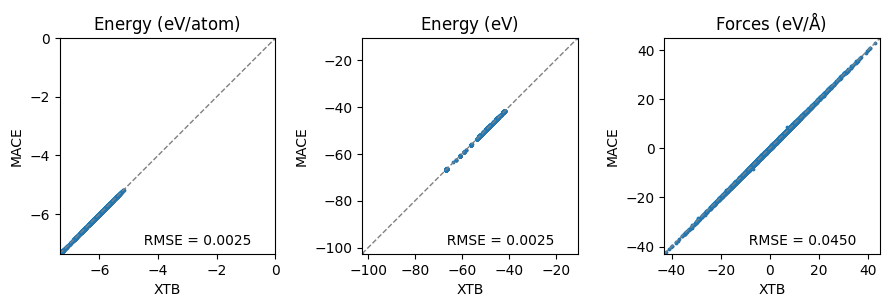

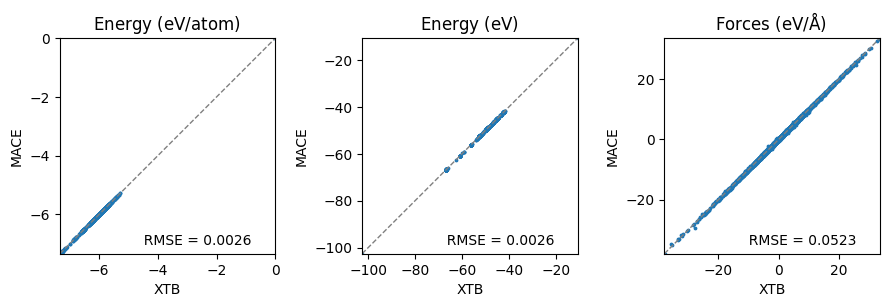

In [3]:
from aseMolec import pltProps as pp
from ase.io import read
import matplotlib.pyplot as plt
from aseMolec import extAtoms as ea
import numpy as np

def plot_RMSEs(db, labs):
    ea.rename_prop_tag(db, 'MACE_energy', 'energy_mace') #Backward compatibility
    ea.rename_prop_tag(db, 'MACE_forces', 'forces_mace') #Backward compatibility
    
    plt.figure(figsize=(9,6), dpi=100)
    plt.subplot(1,3,1)
    pp.plot_prop(ea.get_prop(db, 'bind', '_xtb', True).flatten(), \
                 ea.get_prop(db, 'bind', '_mace', True).flatten(), \
                 title=r'Energy $(\rm eV/atom)$ ', labs=labs, rel=False)
    plt.subplot(1,3,2)
    pp.plot_prop(ea.get_prop(db, 'info', 'energy_xtb', True).flatten(), \
                 ea.get_prop(db, 'info', 'energy_mace', True).flatten(), \
                 title=r'Energy $(\rm eV)$ ', labs=labs, rel=False)
    plt.subplot(1,3,3)
    pp.plot_prop(np.concatenate(ea.get_prop(db, 'arrays', 'forces_xtb')).flatten(), \
                 np.concatenate(ea.get_prop(db, 'arrays', 'forces_mace')).flatten(), \
                 title=r'Forces $\rm (eV/\AA)$ ', labs=labs, rel=False)
    plt.tight_layout()
    return

# data output obtained by running the learned model on the test and train sets (NOT THE SAME !!!)
train_data = read(train_output, ':')
test_data = train_data[:3]+read(test_output, ':') #append the E0s for computing atomization energy errors

plot_RMSEs(train_data, labs=['XTB', 'MACE'])
plot_RMSEs(test_data, labs=['XTB', 'MACE'])

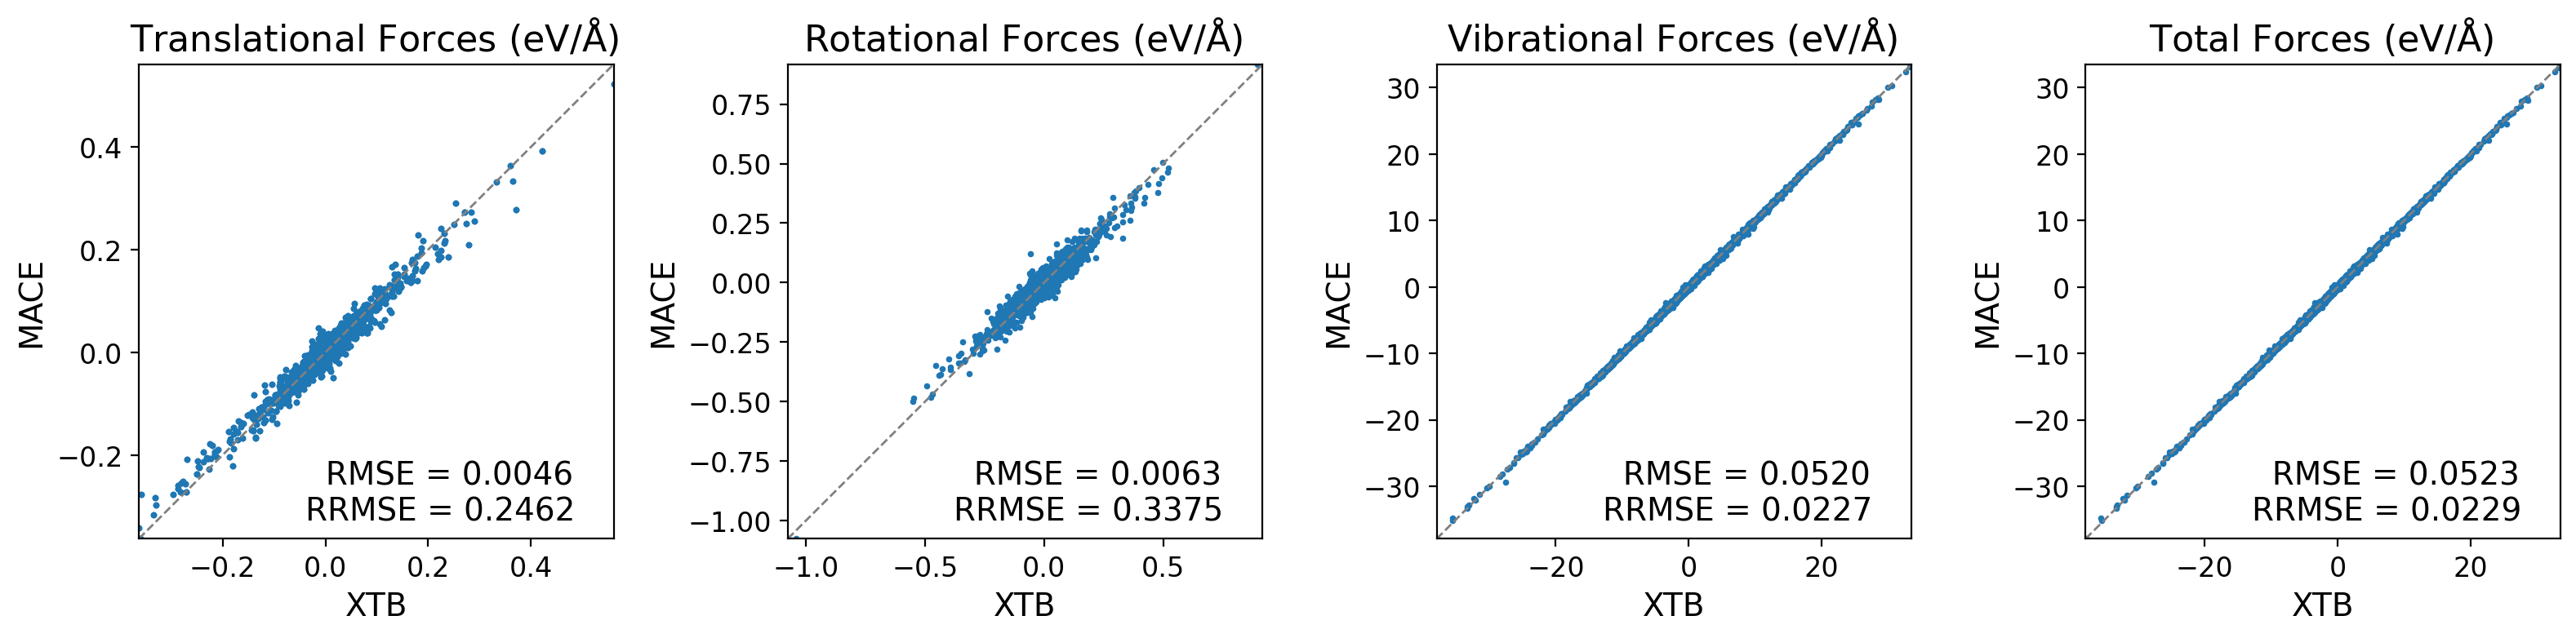

In [6]:
# force decomp for the test output
from aseMolec import pltProps as pp
from aseMolec import anaAtoms as aa


# Set global font size before calling the plotting function
plt.rcParams.update({
    'font.size': 14,          # Change this to desired font size
    'axes.titlesize': 16,     # Title font size
    'axes.labelsize': 14,     # Axis label size
    'xtick.labelsize': 12,    # X-tick size
    'ytick.labelsize': 12,    # Y-tick size
    'legend.fontsize': 12     # Legend size
})




db1 = read(test_output, ':')
ea.rename_prop_tag(db1, 'energy_xtb', 'energy') #Backward compatibility
ea.rename_prop_tag(db1, 'forces_xtb', 'forces') #Backward compatibility

db2 = read(test_output, ':')
ea.rename_prop_tag(db2, 'MACE_energy', 'energy') #Backward compatibility
ea.rename_prop_tag(db2, 'MACE_forces', 'forces') #Backward compatibility

aa.extract_molecs(db1, intra_inter=True)
aa.extract_molecs(db2, intra_inter=True)

pp.plot_trans_rot_vib(db1, db2, labs=['XTB', 'MACE'])

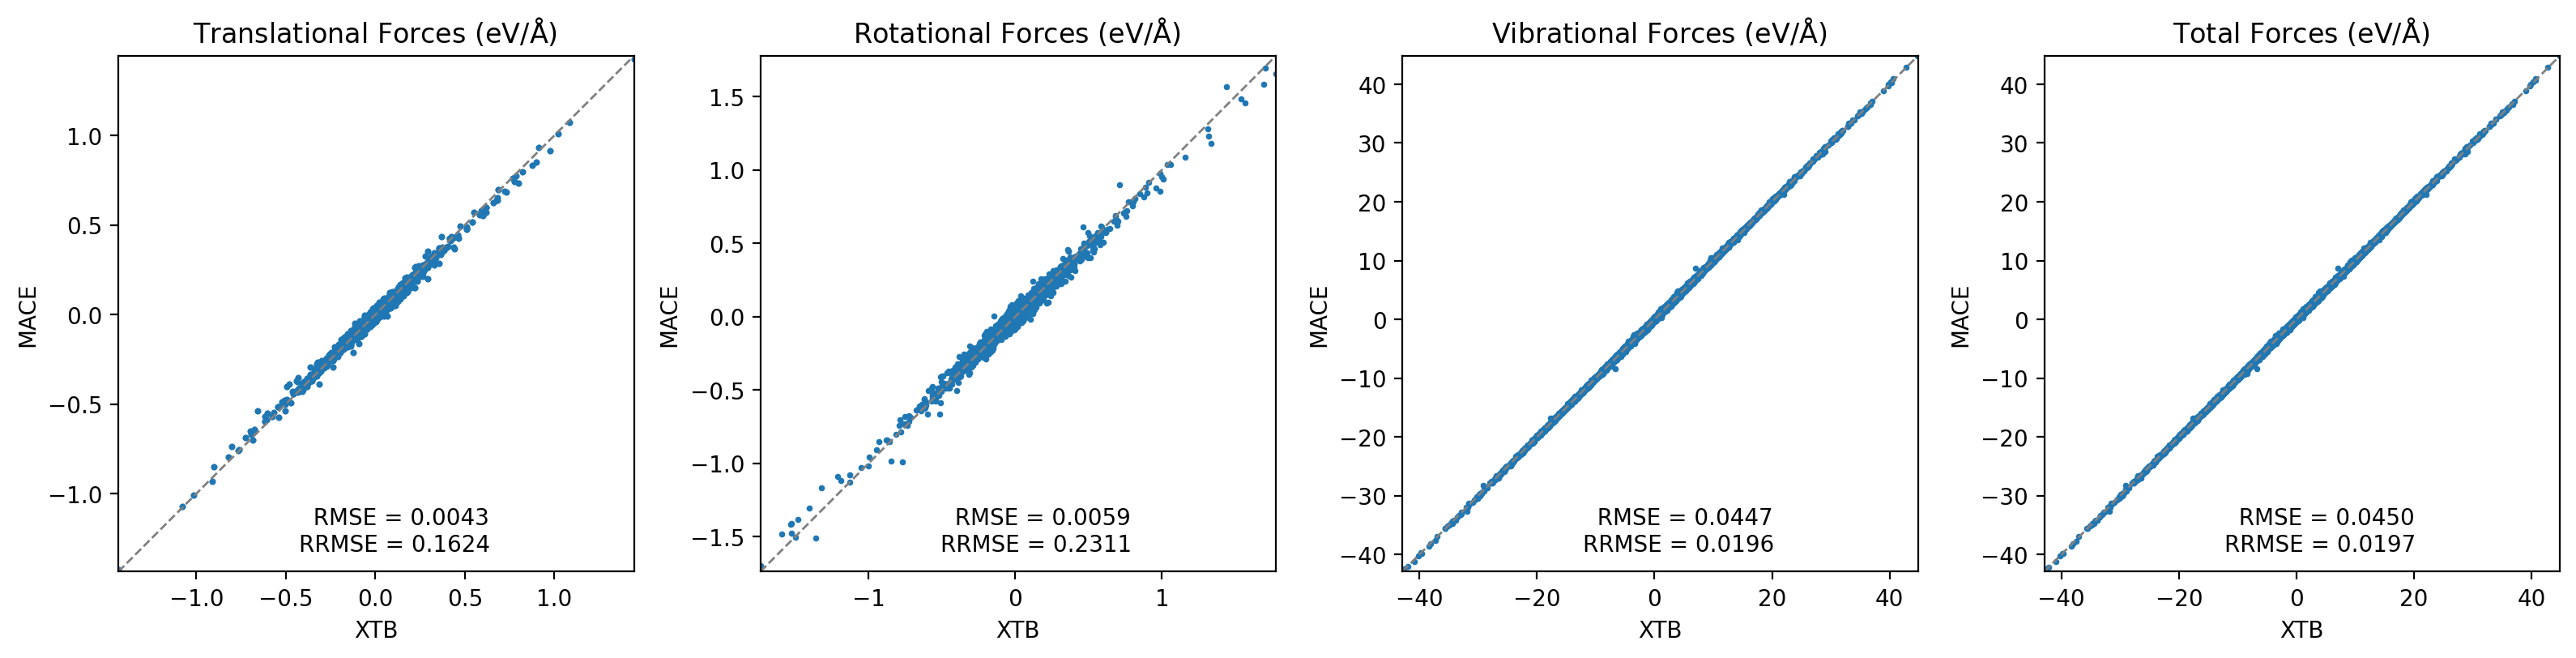

In [5]:
# for the train output
db1 = read(train_output, ':')
ea.rename_prop_tag(db1, 'energy_xtb', 'energy') #Backward compatibility
ea.rename_prop_tag(db1, 'forces_xtb', 'forces') #Backward compatibility

db2 = read(train_output, ':')
ea.rename_prop_tag(db2, 'MACE_energy', 'energy') #Backward compatibility
ea.rename_prop_tag(db2, 'MACE_forces', 'forces') #Backward compatibility

aa.extract_molecs(db1, intra_inter=True)
aa.extract_molecs(db2, intra_inter=True)

pp.plot_trans_rot_vib(db1, db2, labs=['XTB', 'MACE'])